# Breadth-at-1x sensitivity sweep

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

METRIC_STYLE = {
    "contigs": ("Unique contigs",    "#009E73", "--", "s"),
    "rpkm":    ("RPKM (abundance)",  "#E69F00", ":",  "^"),
}
PCT_COL = {"contigs": "pct_contigs_vs_unfiltered", "rpkm": "pct_rpkm_retained"}
METRICS = ["contigs", "rpkm"]

In [2]:
#VIRUSES
VIRAL_CSV = "/Users/skoog/Desktop/sensitivity_analysis_viruses/breadth_sensitivity_summary.csv"
VIRAL_PRIMARY = 0.75

dfv = pd.read_csv(VIRAL_CSV).sort_values("min_covered_fraction").reset_index(drop=True)
dfv

,type,min_covered_fraction,n_detections,pct_detections_vs_unfiltered,n_contigs_detected,pct_contigs_vs_unfiltered,rpkm_sum_retained,pct_rpkm_retained
0,all,0.00,71711,100.0,11271,100.0,10122732.54,100.0
1,all,0.10,37545,52.4,11091,98.4,9059139.60,89.5
2,all,0.50,20691,28.9,10363,91.9,8160717.44,80.6
3,all,0.75,15907,22.2,9610,85.3,7421880.81,73.3


In [3]:
#PLASMIDS

PLASMID_DIR = "/Users/skoog/Desktop/sensitivity_analysis_plasmids"
PLASMID_PRIMARY = 0.50
PLASMID_THRESHOLDS = [0, 0.10, 0.50]
WET_LIST = None

def find_one(fname):
    hits = glob.glob(os.path.join(PLASMID_DIR, "**", fname), recursive=True)
    return sorted(hits, key=len)[0] if hits else None

MCF0    = find_one("coverm_plasmid_mcf0.tsv")
PRIMARY = find_one("coverm_plasmid_multi_ALL.tsv")
NATIVE  = {0.10: find_one("coverm_plasmid_mcf010.tsv"),
           0.50: find_one("coverm_plasmid_mcf050.tsv")}

for k, v in [("mcf0", MCF0), ("primary", PRIMARY), ("0.10", NATIVE[0.10]), ("0.50", NATIVE[0.50])]:
    print(f"{k:8s} {v}")

assert MCF0, "need the uncensored mcf 0 table; the 0.50 run can't reproduce the sweep"

mcf0     /Users/skoog/Desktop/sensitivity_analysis_plasmids/coverm/sensitivity/coverm_plasmid_mcf0.tsv
primary  /Users/skoog/Desktop/sensitivity_analysis_plasmids/coverm/coverm_plasmid_multi_ALL.tsv
0.10     /Users/skoog/Desktop/sensitivity_analysis_plasmids/coverm/sensitivity/coverm_plasmid_mcf010.tsv
0.50     /Users/skoog/Desktop/sensitivity_analysis_plasmids/coverm/sensitivity/coverm_plasmid_mcf050.tsv


In [4]:
STRIP = [".sorted", "_map_sorted_plasmid", "_filt", "_qc"]

def load_coverm(path):
    d = pd.read_csv(path, sep="\t")
    cid = d.columns[0]
    rp = {c[:-5]: c for c in d.columns if c.endswith(" RPKM")}
    cf = {c[:-17]: c for c in d.columns if c.endswith(" Covered Fraction")}
    out = []
    for s in sorted(set(rp) & set(cf)):
        name = s
        for suf in STRIP:
            if name.endswith(suf):
                name = name[:-len(suf)]
        out.append(pd.DataFrame({"sample": name,
                                 "contig": d[cid].astype(str).values,
                                 "rpkm": pd.to_numeric(d[rp[s]], errors="coerce").values,
                                 "cf": pd.to_numeric(d[cf[s]], errors="coerce").values}))
    return pd.concat(out, ignore_index=True).dropna(subset=["rpkm", "cf"])


def ladder(tidy, thresholds):
    base = tidy[tidy["rpkm"] > 0]
    n0, c0, r0 = len(base), base["contig"].nunique(), base["rpkm"].sum()
    rows = []
    for t in thresholds:
        k = base[base["cf"] >= t]
        rows.append({"min_covered_fraction": t,
                     "n_detections": len(k),
                     "n_contigs": k["contig"].nunique(),
                     "sum_rpkm": k["rpkm"].sum(),
                     "pct_detections_vs_unfiltered": 100 * len(k) / n0,
                     "pct_contigs_vs_unfiltered": 100 * k["contig"].nunique() / c0,
                     "pct_rpkm_retained": 100 * k["rpkm"].sum() / r0})
    return pd.DataFrame(rows)


tidy = load_coverm(MCF0)
print(tidy["sample"].nunique(), "samples,", tidy["contig"].nunique(), "contigs")

if WET_LIST:
    wet = {l.strip() for l in open(WET_LIST) if l.strip()}
    tidy["Season"] = np.where(tidy["sample"].isin(wet), "Wet", "Dry")
else:
    tidy["Season"] = "All"

dfp = pd.concat([ladder(g, PLASMID_THRESHOLDS).assign(Season=k, n_samples=g["sample"].nunique())
                 for k, g in tidy.groupby("Season", sort=False)], ignore_index=True)
dfp.to_csv("plasmid_breadth_sensitivity_summary.csv", index=False)
dfp

69 samples, 27836 contigs


,min_covered_fraction,n_detections,n_contigs,sum_rpkm,pct_detections_vs_unfiltered,pct_contigs_vs_unfiltered,pct_rpkm_retained,Season,n_samples
0,0.0,523285,27664,1.324942e+07,100.000000,100.000000,100.000000,All,69
1,0.1,282954,27492,1.249378e+07,54.072637,99.378253,94.296772,All,69
2,0.5,124223,26725,1.048285e+07,23.739071,96.605697,79.119311,All,69


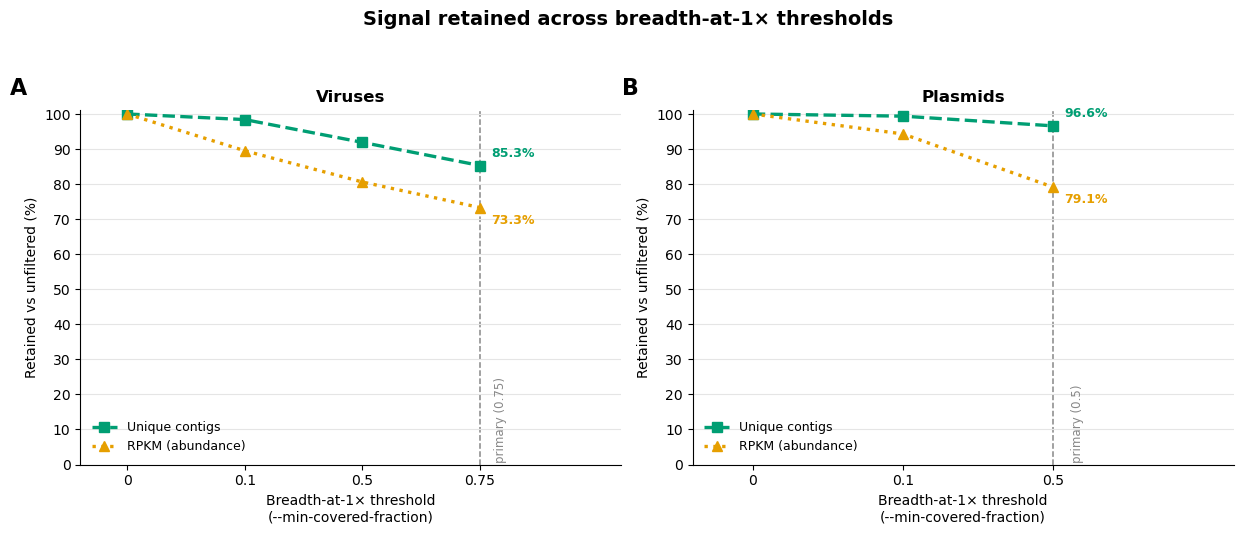

In [5]:
def panel(ax, table, primary, title, group_col=None):
    thr = sorted(table["min_covered_fraction"].unique())
    prim = thr.index(primary)
    groups = list(dict.fromkeys(table[group_col])) if group_col else [None]

    labelled = []
    for gi, gname in enumerate(groups):
        sub = (table if gname is None else table[table[group_col] == gname])
        sub = sub.sort_values("min_covered_fraction")
        x = [thr.index(t) for t in sub["min_covered_fraction"]]
        for key in METRICS:
            name, color, ls, mk = METRIC_STYLE[key]
            y = sub[PCT_COL[key]].values
            lab = name if len(groups) == 1 else f"{gname} - {name}"
            ax.plot(x, y, linestyle=ls, marker=mk, color=color, lw=2.4, ms=7,
                    alpha=1.0 if gi == 0 else 0.55, label=lab)
            labelled.append((color, float(y[list(sub["min_covered_fraction"]).index(primary)])))

    ax.axvline(prim, color="#888888", ls="--", lw=1.1, zorder=1)
    ax.set_ylim(0, 101)

    labelled.sort(key=lambda p: -p[1])
    offs = np.linspace(9, -9, len(labelled)) if len(labelled) > 1 else [0]
    for (color, yv), off in zip(labelled, offs):
        ax.annotate(f"{yv:.1f}%", (prim, yv), textcoords="offset points",
                    xytext=(8, off), va="center", color=color, fontsize=9, fontweight="bold")

    ax.set_xticks(range(len(thr)))
    ax.set_xticklabels([f"{t:g}" for t in thr])
    ax.set_xlim(-0.4, len(thr) - 1 + 1.2)
    ax.set_xlabel("Breadth-at-1\u00d7 threshold\n(--min-covered-fraction)")
    ax.set_ylabel("Retained vs unfiltered (%)")
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.grid(axis="y", color="#E5E5E5", lw=0.8, zorder=0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.text(prim + 0.12, 0.5, f"primary ({primary:g})", color="#888888",
            fontsize=8.5, ha="left", va="bottom", rotation=90)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(loc="lower left", frameon=False, fontsize=9)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.4))
panel(ax1, dfv, VIRAL_PRIMARY, "Viruses")
panel(ax2, dfp, PLASMID_PRIMARY, "Plasmids",
      group_col="Season" if dfp["Season"].nunique() > 1 else None)

for ax, lab in [(ax1, "A"), (ax2, "B")]:
    ax.text(-0.13, 1.03, lab, transform=ax.transAxes, fontsize=16, fontweight="bold", va="bottom")

fig.suptitle("Signal retained across breadth-at-1\u00d7 thresholds", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("breadth_sensitivity.svg")
fig.savefig("breadth_sensitivity.png", dpi=300)
plt.show()